# Phase 6: Business Category Analysis

## Purpose

This notebook analyzes important business categories in the retail orders dataset.

Project 1 focused on data cleaning and validation.  
Project 2 focuses on Exploratory Data Analysis.

In this phase, the goal is to analyze product performance, payment method behavior, coupon usage, referral source performance, and order status patterns.

Main questions:

- Which products generate the highest revenue?
- Which payment methods are most used?
- Do coupon users spend more than non-coupon users?
- Which referral sources bring the most revenue?
- What are the most common order statuses?
- Are cancelled or returned orders a business concern?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv("../data/processed/ecommerce_orders_project2_trend_correlation_ready.csv")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,HasCoupon,TotalPrice_Outlier_IQR,Year,Month,MonthName,YearMonth
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,Coupon Used,Normal,2023,1,January,2023-01
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,Coupon Used,Normal,2024,8,August,2024-08
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,Coupon Used,Normal,2024,2,February,2024-02
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,Coupon Used,Normal,2023,10,October,2023-10
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,Coupon Used,Normal,2025,5,May,2025-05


In [3]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   OrderID                 1200 non-null   object        
 1   Date                    1200 non-null   datetime64[ns]
 2   CustomerID              1200 non-null   object        
 3   Product                 1200 non-null   object        
 4   Quantity                1200 non-null   int64         
 5   UnitPrice               1200 non-null   float64       
 6   ShippingAddress         1200 non-null   object        
 7   PaymentMethod           1200 non-null   object        
 8   OrderStatus             1200 non-null   object        
 9   TrackingNumber          1200 non-null   object        
 10  ItemsInCart             1200 non-null   int64         
 11  CouponCode              1200 non-null   object        
 12  ReferralSource          1200 non-null   object  

In [4]:
os.makedirs("../reports/figures", exist_ok=True)

print("Figures folder is ready.")

Figures folder is ready.


In [5]:
#product performance summary
product_summary = (
    df.groupby("Product")
    .agg(
        TotalRevenue=("TotalPrice", "sum"),
        TotalOrders=("OrderID", "nunique"),
        TotalQuantitySold=("Quantity", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .reset_index()
)

product_summary["TotalRevenue"] = product_summary["TotalRevenue"].round(2)
product_summary["AverageOrderValue"] = product_summary["AverageOrderValue"].round(2)

product_summary = product_summary.sort_values(by="TotalRevenue", ascending=False)

product_summary

,Product,TotalRevenue,TotalOrders,TotalQuantitySold,AverageOrderValue
0,Chair,195620.11,178,562,1098.99
5,Printer,195612.61,181,542,1080.73
2,Laptop,192126.56,173,535,1110.56
6,Tablet,186568.95,179,497,1042.28
3,Monitor,175651.41,163,480,1077.62
1,Desk,167459.93,170,508,985.06
4,Phone,151722.39,156,411,972.58


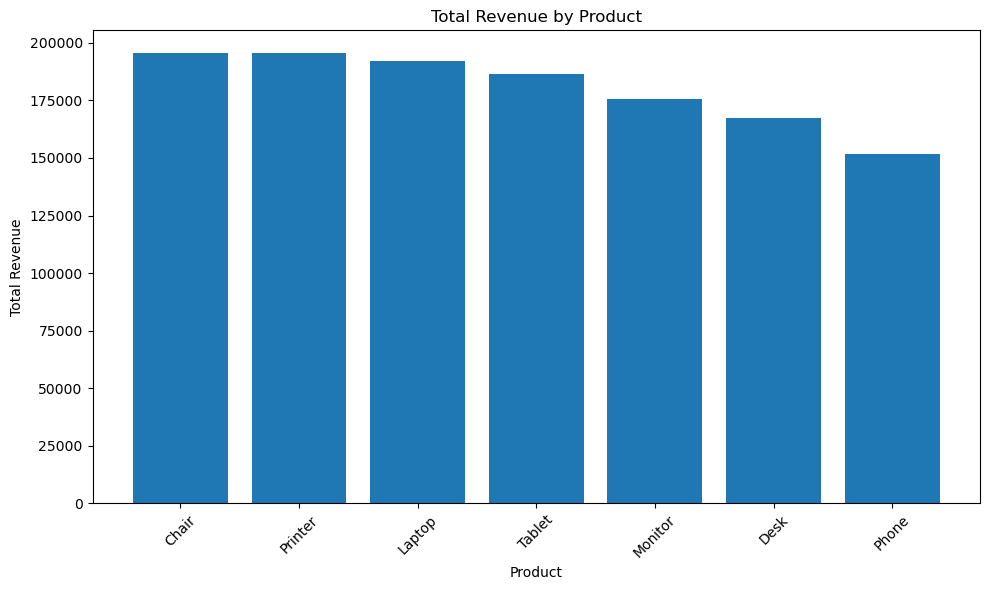

In [6]:
#product revenue chart
plt.figure(figsize=(10, 6))
plt.bar(product_summary["Product"], product_summary["TotalRevenue"])
plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/revenue_by_product.png")
plt.show()

In [7]:
product_summary.to_csv("../reports/product_performance_summary.csv", index=False)

print("Product performance summary saved successfully.")

Product performance summary saved successfully.


In [8]:
#payment method analysis
payment_summary = (
    df.groupby("PaymentMethod")
    .agg(
        TotalRevenue=("TotalPrice", "sum"),
        TotalOrders=("OrderID", "nunique"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .reset_index()
)

payment_summary["TotalRevenue"] = payment_summary["TotalRevenue"].round(2)
payment_summary["AverageOrderValue"] = payment_summary["AverageOrderValue"].round(2)

payment_summary = payment_summary.sort_values(by="TotalRevenue", ascending=False)

payment_summary

,PaymentMethod,TotalRevenue,TotalOrders,AverageOrderValue
1,Credit Card,263847.63,234,1127.55
4,Online,262442.94,258,1017.22
0,Cash,259786.29,246,1056.04
3,Gift Card,246323.92,230,1070.97
2,Debit Card,232361.18,232,1001.56


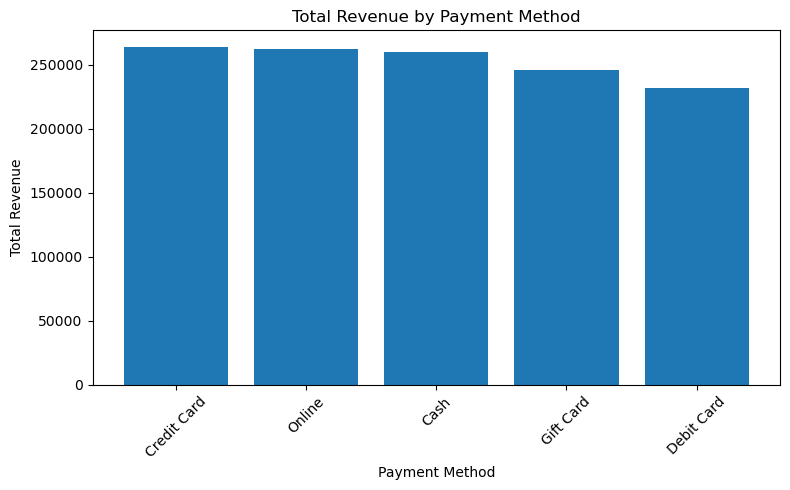

In [9]:
#Payment method revenue chart
plt.figure(figsize=(8, 5))
plt.bar(payment_summary["PaymentMethod"], payment_summary["TotalRevenue"])
plt.title("Total Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/revenue_by_payment_method.png")
plt.show()

In [10]:
payment_summary.to_csv("../reports/payment_method_summary.csv", index=False)

print("Payment method summary saved successfully.")

Payment method summary saved successfully.


In [11]:
#Coupon Usage Analysis
coupon_summary = (
    df.groupby("HasCoupon")
    .agg(
        TotalRevenue=("TotalPrice", "sum"),
        TotalOrders=("OrderID", "nunique"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .reset_index()
)

coupon_summary["TotalRevenue"] = coupon_summary["TotalRevenue"].round(2)
coupon_summary["AverageOrderValue"] = coupon_summary["AverageOrderValue"].round(2)

coupon_summary

,HasCoupon,TotalRevenue,TotalOrders,AverageOrderValue
0,Coupon Used,942360.55,891,1057.64
1,No Coupon,322401.41,309,1043.37


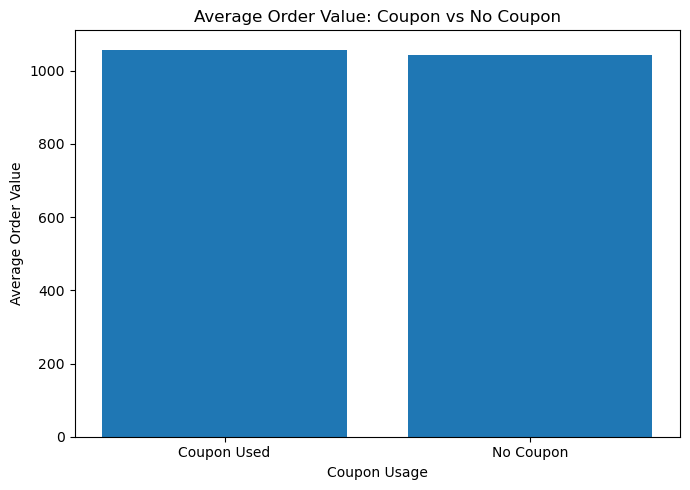

In [12]:
#Coupon average order value chart
plt.figure(figsize=(7, 5))
plt.bar(coupon_summary["HasCoupon"], coupon_summary["AverageOrderValue"])
plt.title("Average Order Value: Coupon vs No Coupon")
plt.xlabel("Coupon Usage")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.savefig("../reports/figures/aov_coupon_vs_no_coupon.png")
plt.show()

In [13]:
#Coupon code performance
coupon_code_summary = (
    df.groupby("CouponCode")
    .agg(
        TotalRevenue=("TotalPrice", "sum"),
        TotalOrders=("OrderID", "nunique"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .reset_index()
)

coupon_code_summary["TotalRevenue"] = coupon_code_summary["TotalRevenue"].round(2)
coupon_code_summary["AverageOrderValue"] = coupon_code_summary["AverageOrderValue"].round(2)

coupon_code_summary = coupon_code_summary.sort_values(by="TotalRevenue", ascending=False)

coupon_code_summary

,CouponCode,TotalRevenue,TotalOrders,AverageOrderValue
0,FREESHIP,335036.99,313,1070.41
1,NO_COUPON,322401.41,309,1043.37
2,SAVE10,304840.02,286,1065.87
3,WINTER15,302483.54,292,1035.90


In [14]:
coupon_summary.to_csv("../reports/coupon_usage_summary.csv", index=False)
coupon_code_summary.to_csv("../reports/coupon_code_summary.csv", index=False)

print("Coupon summaries saved successfully.")

Coupon summaries saved successfully.


In [15]:
#Referral Source Analysis
referral_summary = (
    df.groupby("ReferralSource")
    .agg(
        TotalRevenue=("TotalPrice", "sum"),
        TotalOrders=("OrderID", "nunique"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .reset_index()
)

referral_summary["TotalRevenue"] = referral_summary["TotalRevenue"].round(2)
referral_summary["AverageOrderValue"] = referral_summary["AverageOrderValue"].round(2)

referral_summary = referral_summary.sort_values(by="TotalRevenue", ascending=False)

referral_summary

,ReferralSource,TotalRevenue,TotalOrders,AverageOrderValue
3,Instagram,275285.45,259,1062.88
0,Email,261808.55,250,1047.23
2,Google,250441.48,241,1039.18
1,Facebook,250410.90,228,1098.29
4,Referral,226815.58,222,1021.69


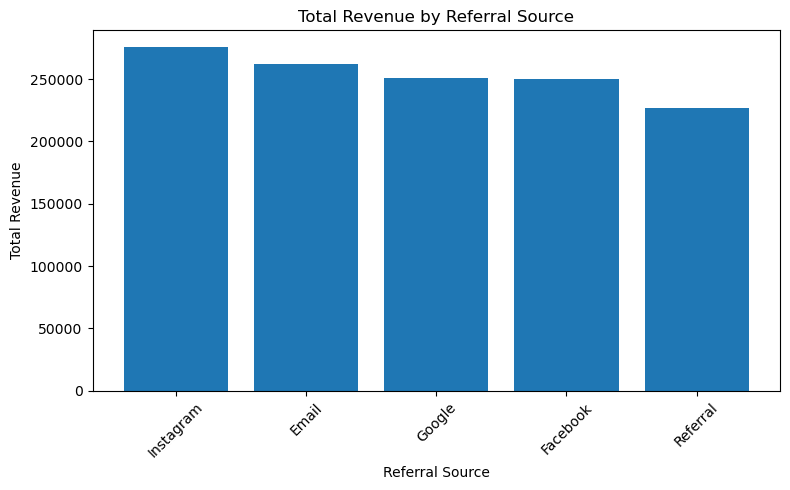

In [16]:
#Referral source revenue chart
plt.figure(figsize=(8, 5))
plt.bar(referral_summary["ReferralSource"], referral_summary["TotalRevenue"])
plt.title("Total Revenue by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/revenue_by_referral_source.png")
plt.show()

In [17]:
referral_summary.to_csv("../reports/referral_source_summary.csv", index=False)

print("Referral source summary saved successfully.")

Referral source summary saved successfully.


In [18]:
#Order Status Analysis
order_status_summary = (
    df.groupby("OrderStatus")
    .agg(
        TotalRevenue=("TotalPrice", "sum"),
        TotalOrders=("OrderID", "nunique"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .reset_index()
)

order_status_summary["TotalRevenue"] = order_status_summary["TotalRevenue"].round(2)
order_status_summary["AverageOrderValue"] = order_status_summary["AverageOrderValue"].round(2)

order_status_summary = order_status_summary.sort_values(by="TotalOrders", ascending=False)

order_status_summary

,OrderStatus,TotalRevenue,TotalOrders,AverageOrderValue
0,Cancelled,276396.21,250,1105.58
3,Returned,243277.70,247,984.93
2,Pending,256328.15,237,1081.55
4,Shipped,246159.58,235,1047.49
1,Delivered,242600.32,231,1050.22


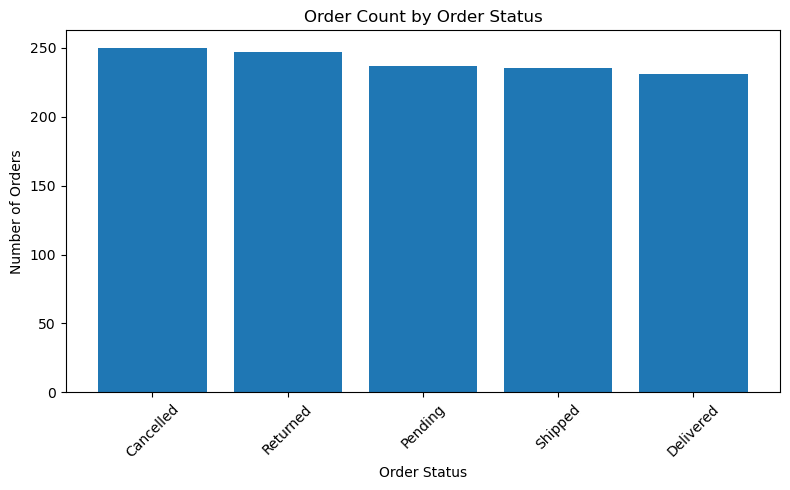

In [19]:
#Order status chart
plt.figure(figsize=(8, 5))
plt.bar(order_status_summary["OrderStatus"], order_status_summary["TotalOrders"])
plt.title("Order Count by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/orders_by_status.png")
plt.show()

In [20]:
order_status_summary.to_csv("../reports/order_status_summary.csv", index=False)

print("Order status summary saved successfully.")

Order status summary saved successfully.


In [21]:
#Risk Analysis: Cancelled and Returned Orders
df["RiskStatus"] = np.where(
    df["OrderStatus"].isin(["Cancelled", "Returned"]),
    "Risk Order",
    "Normal Order"
)

df["RiskStatus"].value_counts()

RiskStatus
Normal Order    703
Risk Order      497
Name: count, dtype: int64

In [22]:
#Risk orders by product
risk_by_product = (
    df.groupby(["Product", "RiskStatus"])
    .agg(
        TotalOrders=("OrderID", "nunique")
    )
    .reset_index()
)

risk_by_product_pivot = risk_by_product.pivot(
    index="Product",
    columns="RiskStatus",
    values="TotalOrders"
).fillna(0)

risk_by_product_pivot["TotalOrders"] = risk_by_product_pivot.sum(axis=1)
risk_by_product_pivot["RiskOrderRate"] = (
    risk_by_product_pivot["Risk Order"] / risk_by_product_pivot["TotalOrders"] * 100
).round(2)

risk_by_product_pivot = risk_by_product_pivot.sort_values(by="RiskOrderRate", ascending=False)

risk_by_product_pivot

RiskStatus,Normal Order,Risk Order,TotalOrders,RiskOrderRate
Product,,,,
Monitor,92,71,163,43.56
Tablet,102,77,179,43.02
Laptop,99,74,173,42.77
Chair,105,73,178,41.01
Printer,108,73,181,40.33
Phone,94,62,156,39.74
Desk,103,67,170,39.41


In [23]:
#Risk orders by payment method
risk_by_payment = (
    df.groupby(["PaymentMethod", "RiskStatus"])
    .agg(
        TotalOrders=("OrderID", "nunique")
    )
    .reset_index()
)

risk_by_payment_pivot = risk_by_payment.pivot(
    index="PaymentMethod",
    columns="RiskStatus",
    values="TotalOrders"
).fillna(0)

risk_by_payment_pivot["TotalOrders"] = risk_by_payment_pivot.sum(axis=1)
risk_by_payment_pivot["RiskOrderRate"] = (
    risk_by_payment_pivot["Risk Order"] / risk_by_payment_pivot["TotalOrders"] * 100
).round(2)

risk_by_payment_pivot = risk_by_payment_pivot.sort_values(by="RiskOrderRate", ascending=False)

risk_by_payment_pivot

RiskStatus,Normal Order,Risk Order,TotalOrders,RiskOrderRate
PaymentMethod,,,,
Gift Card,128,102,230,44.35
Credit Card,131,103,234,44.02
Cash,140,106,246,43.09
Debit Card,137,95,232,40.95
Online,167,91,258,35.27


In [24]:
risk_by_product_pivot.to_csv("../reports/risk_orders_by_product.csv")
risk_by_payment_pivot.to_csv("../reports/risk_orders_by_payment_method.csv")

print("Risk analysis summaries saved successfully.")

Risk analysis summaries saved successfully.


In [25]:
df.to_csv("../data/processed/ecommerce_orders_project2_final_eda_dataset.csv", index=False)

print("Final Project 2 EDA dataset saved successfully.")

Final Project 2 EDA dataset saved successfully.


## Business Category Analysis Summary

This phase analyzed the main business categories in the retail orders dataset.

The categories analyzed were:

- Product
- PaymentMethod
- Coupon usage
- CouponCode
- ReferralSource
- OrderStatus
- RiskStatus

### Product Analysis

Product analysis was used to identify which products generated the highest revenue, highest order count, and highest average order value.

This helps understand which products contribute most to business performance.

### Payment Method Analysis

Payment method analysis was used to understand how customers prefer to pay and which payment methods generate the most revenue.

This helps identify customer payment behavior.

### Coupon Usage Analysis

Coupon usage analysis compared coupon users and non-coupon users.

This helps understand whether coupon usage is connected with higher order value.

### Referral Source Analysis

Referral source analysis was used to compare marketing channels such as Instagram, Email, Google, Facebook, and Referral.

This helps identify which channels bring the most revenue and orders.

### Order Status Analysis

Order status analysis was used to understand how many orders were delivered, shipped, pending, cancelled, or returned.

Cancelled and returned orders are important because they can reduce actual business performance.

### Risk Order Analysis

A new RiskStatus column was created.

Cancelled and returned orders were labeled as Risk Orders.  
Delivered, shipped, and pending orders were labeled as Normal Orders.

This helps identify which products and payment methods may need more attention.

### Conclusion

This phase converted the dataset from simple rows and columns into business insights.

The analysis is now ready to support:

- SQL business analysis
- Power BI dashboard creation
- GitHub README insights
- LinkedIn project post
- Portfolio presentation